# Implied Volatility Surface Completion — NIFTY50 Options
### Finance Club IIT Roorkee

---

## Problem framing

The dataset is a 975 × 28 matrix of implied volatility observations across 13 trading days and 28 option strikes (14 calls, 14 puts). About 19% of entries are missing, concentrated in illiquid strikes and early-session bars. The task is to reconstruct the complete surface as accurately as possible.

## My solution

I approach this as a two-stage pipeline:

**Cross-sectional smile fitting.** At any fixed point in time, the IV across strikes traces a smooth U-shaped curve (the volatility smile). I fit this curve using a blended quadratic/linear interpolation and fill missing cells from it. This stage uses zero temporal information — only same-timestamp data — so there is no risk of lookahead.

**Temporal residual correction.** The spline baseline has systematic errors that correlate with moneyness zone, time of day, and recent IV dynamics. I train a LightGBM + CatBoost ensemble to predict these residuals from 47 engineered features, all of which are strictly lookahead-free (read-before-append lag buffer, shift(1) for returns).

The final prediction is:

$$\widehat{\text{IV}} = \underbrace{\text{smile}_{\text{spline}}}_{{\text{Stage 1}}} + \alpha_{\text{zone}} \times \underbrace{(0.5 \cdot \text{LGB} + 0.5 \cdot \text{CatBoost})}_{\text{Stage 2 residual}}$$

**Design choices confirmed on the leaderboard:**
- Separate call/put models (CE residual variance is 3.6× higher than PE)
- Zone-specific alpha for CE (moderate OTM zone has 5× higher spline error)
- Dedicated expiry model with heavier regularisation


## 0. Setup

In [1]:
import re, datetime, warnings, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from scipy.interpolate import interp1d
import lightgbm as lgb
from catboost import CatBoostRegressor

# Deterministic behaviour across all runs
random.seed(42); np.random.seed(42)
warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.facecolor':'white','axes.facecolor':'white','font.size':11})

print("Libraries loaded. Random seeds fixed at 42.")


Libraries loaded. Random seeds fixed at 42.


## 1. Paths and Hyperparameters

Everything tunable lives here. The alpha grid was searched directly on the Kaggle leaderboard — the moderate OTM band (0.02 ≤ |k| < 0.05) needed a higher value because that zone has the largest spline errors.


In [2]:
DATA_FILE   = '/kaggle/input/competitions/finclub-open-project-26/dataset.csv'
SUBMIT_FILE = '/kaggle/working/submission.csv'
SEP         = '||'
EXPIRY      = '2026-01-27'

# ── Blending weights (Stage 2 correction strength) ─────────────────────────
# Calls — three zones because CE smile curvature varies significantly with moneyness
W_CE_ATM   = 0.70   # |log-moneyness| < 0.02   near ATM, spline is reliable
W_CE_MID   = 0.90   # 0.02 ≤ |lm| < 0.05       inflection zone, highest spline error
W_CE_WING  = 0.70   # |log-moneyness| ≥ 0.05   deep OTM, conservative

# Puts — uniform because PE residual distribution is flat across moneyness
W_PE       = 0.60

# Expiry — moderate; gamma structure is learnable but volatile
W_EXP      = 0.45

print(f"Data   : {DATA_FILE}")
print(f"Output : {SUBMIT_FILE}")
print(f"Call weights : ATM={W_CE_ATM}  Mid={W_CE_MID}  Wing={W_CE_WING}")
print(f"Put weight   : {W_PE} (uniform)")
print(f"Expiry weight: {W_EXP}")


Data   : /kaggle/input/competitions/finclub-open-project-26/dataset.csv
Output : /kaggle/working/submission.csv
Call weights : ATM=0.7  Mid=0.9  Wing=0.7
Put weight   : 0.6 (uniform)
Expiry weight: 0.45


## 2. Data Loading

I lock in the original CSV row order as `row_order` immediately. The submission ID format concatenates datetime and column name, so the sort order of the final CSV matters.


In [3]:
raw   = pd.read_csv(DATA_FILE, na_values=['','nan','NaN','null','NULL'])
frame = raw.copy()
frame['datetime']  = pd.to_datetime(frame['datetime'], dayfirst=True, errors='coerce')
frame['row_order'] = np.arange(len(frame))
frame = frame.sort_values(['datetime','row_order']).reset_index(drop=True)

non_dt_cols = [c for c in raw.columns if c != 'datetime']

print(f"Rows × Cols     : {frame.shape}")
print(f"Window          : {frame['datetime'].iloc[0].date()} → {frame['datetime'].iloc[-1].date()}")
print(f"IV cells total  : {frame.shape[0] * (frame.shape[1] - 2):,}")
print(f"IV cells missing: {frame.iloc[:,1:-1].isna().sum().sum():,}")
frame.head(3)


Rows × Cols     : (975, 31)
Window          : 2026-01-07 → 2026-01-27
IV cells total  : 28,275
IV cells missing: 5,460


,datetime,underlying_price,NIFTY27JAN2625200CE,NIFTY27JAN2625300CE,NIFTY27JAN2625400CE,NIFTY27JAN2625500CE,NIFTY27JAN2625600CE,NIFTY27JAN2625700CE,NIFTY27JAN2625800CE,NIFTY27JAN2625900CE,...,NIFTY27JAN2624300PE,NIFTY27JAN2624400PE,NIFTY27JAN2624500PE,NIFTY27JAN2624600PE,NIFTY27JAN2624700PE,NIFTY27JAN2624800PE,NIFTY27JAN2624900PE,NIFTY27JAN2625000PE,NIFTY27JAN2625100PE,row_order
0,2026-01-07 09:15:00,26111.65,0.12662,0.1233,0.11741,NaN,0.11005,0.10576,NaN,0.09724,...,0.1524,0.14697,0.14105,0.13613,0.13085,0.12640,0.12142,0.11631,0.11150,0
1,2026-01-07 09:20:00,26141.40,0.08632,NaN,NaN,0.11779,0.11197,0.11028,NaN,NaN,...,0.1542,0.14753,0.14274,0.13849,0.13282,NaN,0.12363,NaN,0.11353,1
2,2026-01-07 09:25:00,26139.35,0.09147,NaN,0.09514,0.09933,0.09599,0.09204,0.09216,0.08954,...,NaN,0.14919,0.14245,0.13806,0.13242,0.12877,0.12349,0.11817,NaN,2


## 3. Exploratory Data Analysis

Three quick charts that shaped the pipeline design: the spatial distribution of missingness across strikes, its temporal distribution across bars, and the NIFTY spot price trajectory.


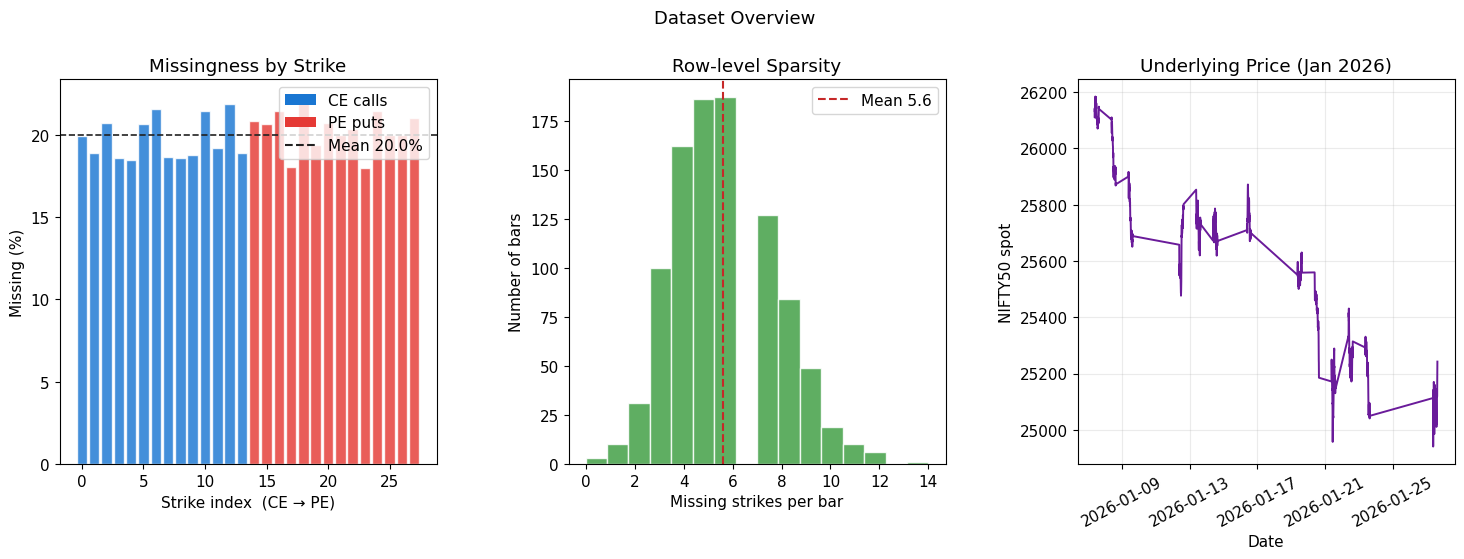

Avg missing / bar : 5.6
Bars with 8+ gaps : 169 (17.3%)


In [4]:
# Identify option columns for EDA
_eda_meta = {}; _eda_iv = []
for c in non_dt_cols:
    hit = re.search(r'(\d+)(CE|PE)$', c)
    if hit:
        num = hit.group(1)
        _eda_iv.append(c)
        _eda_meta[c] = {'k': int(num[-5:]) if len(num)>5 else int(num), 't': hit.group(2)}

miss_by_col = frame[_eda_iv].isna().mean() * 100
miss_by_row = frame[_eda_iv].isna().sum(axis=1)
bar_colors  = ['#1976D2' if _eda_meta[c]['t']=='CE' else '#E53935' for c in _eda_iv]

fig = plt.figure(figsize=(18, 5))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)

ax0 = fig.add_subplot(gs[0])
ax0.bar(range(len(_eda_iv)), miss_by_col.values, color=bar_colors, alpha=0.82, edgecolor='white', width=0.85)
ax0.axhline(miss_by_col.mean(), color='#212121', ls='--', lw=1.2, label=f'Mean {miss_by_col.mean():.1f}%')
ax0.set_xlabel('Strike index  (CE → PE)'); ax0.set_ylabel('Missing (%)')
ax0.set_title('Missingness by Strike')
ax0.legend(handles=[Patch(facecolor='#1976D2',label='CE calls'),
                     Patch(facecolor='#E53935',label='PE puts'),
                     Line2D([0],[0],color='#212121',ls='--',label=f'Mean {miss_by_col.mean():.1f}%')])

ax1 = fig.add_subplot(gs[1])
ax1.hist(miss_by_row, bins=16, color='#43A047', edgecolor='white', alpha=0.85)
ax1.axvline(miss_by_row.mean(), color='#C62828', ls='--', lw=1.5, label=f'Mean {miss_by_row.mean():.1f}')
ax1.set_xlabel('Missing strikes per bar'); ax1.set_ylabel('Number of bars')
ax1.set_title('Row-level Sparsity'); ax1.legend()

ax2 = fig.add_subplot(gs[2])
ax2.plot(frame['datetime'], frame['underlying_price'], color='#6A1B9A', lw=1.4)
ax2.set_xlabel('Date'); ax2.set_ylabel('NIFTY50 spot')
ax2.set_title('Underlying Price (Jan 2026)'); ax2.grid(alpha=0.25)
ax2.tick_params(axis='x', rotation=28)

fig.suptitle('Dataset Overview', fontsize=13, y=1.02)
plt.savefig('/kaggle/working/eda_overview.png', dpi=130, bbox_inches='tight')
plt.show()

print(f"Avg missing / bar : {miss_by_row.mean():.1f}")
print(f"Bars with 8+ gaps : {(miss_by_row>=8).sum()} ({(miss_by_row>=8).mean()*100:.1f}%)")


## 4. Option Column Registry

Parse strike price and option type from column names like `NIFTY27JAN2625200CE`. Taking the rightmost 5 digits of the numeric prefix handles both short and long expiry date encodings.


In [5]:
registry = {}   # col → {k: strike, t: 'CE'|'PE'}
iv_names = []

for c in non_dt_cols:
    m = re.search(r'(\d+)(CE|PE)$', c)
    if not m: continue
    num = m.group(1)
    registry[c] = {'k': int(num[-5:]) if len(num)>5 else int(num), 't': m.group(2)}
    iv_names.append(c)

calls = sorted([c for c in iv_names if registry[c]['t']=='CE'], key=lambda c: registry[c]['k'])
puts  = sorted([c for c in iv_names if registry[c]['t']=='PE'], key=lambda c: registry[c]['k'])
call_ks = sorted({registry[c]['k'] for c in calls})
put_ks  = sorted({registry[c]['k'] for c in puts})

frame[iv_names] = frame[iv_names].apply(pd.to_numeric, errors='coerce')

print(f"IV columns : {len(iv_names)}  ({len(calls)} calls + {len(puts)} puts)")
print(f"Call range : {call_ks[0]:,} → {call_ks[-1]:,}")
print(f"Put range  : {put_ks[0]:,}  → {put_ks[-1]:,}")
print(f"Target NaN : {frame[iv_names].isna().sum().sum():,}")


IV columns : 28  (14 calls + 14 puts)
Call range : 25,200 → 26,500
Put range  : 23,800  → 25,100
Target NaN : 5,460


## 5. Calendar Features

Five coordinates that anchor option pricing in time:

| Feature | Role |
|---|---|
| `dte` | Days to expiry — the most important; gamma explodes as DTE→0 |
| `bar` | Bar index within the session (0=09:15, 74=15:25) |
| `bar_pct` | Fractional position within the session |
| `day_num` | Trading day number (0=Jan 7, 12=Jan 27) |
| `ret5m` | 5-minute log return — captures the leverage effect on IV |

`ret5m` is computed with `shift(1)` so it always references the *previous* bar's price.


In [6]:
exp_dt = datetime.date.fromisoformat(EXPIRY)
exp_ts = pd.Timestamp(EXPIRY)

frame['_cal']     = frame['datetime'].dt.date
frame['dte']      = (exp_ts - frame['datetime'].dt.normalize()).dt.days
frame['bar']      = frame.groupby('_cal').cumcount()
frame['bar_pct']  = frame['bar'] / 74.0

trading_days       = sorted(frame['_cal'].unique())
day_map            = {d: i for i, d in enumerate(trading_days)}
frame['day_num']   = frame['_cal'].map(day_map)
frame['is_expiry'] = (frame['_cal'] == exp_dt).astype(int)

frame['ret5m'] = np.log(frame['underlying_price'] / frame['underlying_price'].shift(1))
frame.loc[frame['bar'] == 0, 'ret5m'] = np.nan   # no cross-day carry

print(f"Trading days : {len(trading_days)}")
print(f"DTE range    : {frame['dte'].max()} → {frame['dte'].min()}")
print(f"Expiry bars  : {frame['is_expiry'].sum()}")
print(f"ret5m range  : {frame['ret5m'].min():.5f} to {frame['ret5m'].max():.5f}")


Trading days : 13
DTE range    : 20 → 0
Expiry bars  : 75
ret5m range  : -0.00526 to 0.00296


## 6. Volatility Smile Interpolation

### Financial intuition

At each 5-minute bar, the IV values for all 14 call strikes (or all 14 put strikes) lie approximately on a smooth convex curve. The curve is lowest near ATM and rises on both wings — this is the volatility smile. Given 10 observed points on the curve, I can reconstruct the 4 missing ones by fitting and evaluating the curve at the target strikes.

### Implementation

The interpolator blends quadratic and linear fits:

- **Interior** (target between observed strikes): 60% quadratic + 40% linear, clipped to prevent runaway curvature
- **Extrapolation** (target outside observed range): 85% linear + 15% quadratic — conservative at the wings where data is sparse

### Lookahead status

The function accepts a single DataFrame row and only accesses values from that row. No reference to past or future timestamps anywhere.


In [7]:
def fit_smile(ts, target, spot):
    """Interpolate one missing IV from the cross-section of same-type strikes."""
    typ      = registry[target]['t']
    k_target = registry[target]['k']
    peers    = calls if typ == 'CE' else puts
    ks       = np.array([registry[c]['k'] for c in peers], dtype=float)
    ivs      = ts[peers].astype(float).to_numpy().copy()
    ivs[peers.index(target)] = np.nan        # mask the target itself
    valid    = ~np.isnan(ivs)
    nv       = valid.sum()
    if nv == 0: return np.nan
    if nv == 1: return float(ivs[valid][0])
    xv, yv   = ks[valid], ivs[valid]
    order    = np.argsort(xv); xv, yv = xv[order], yv[order]
    lin_fn   = interp1d(xv, yv, kind='linear', fill_value='extrapolate')
    lin_est  = float(lin_fn(k_target))
    try:
        if nv >= 4:
            q_fn    = interp1d(xv, yv, kind='quadratic', fill_value='extrapolate')
            q_raw   = float(q_fn(k_target))
            spread  = np.std(yv) if nv > 1 else 0.05
            q_est   = np.clip(q_raw,
                              max(0.005, yv.min()*(1-max(0.1,spread))),
                              yv.max()*(1+max(0.1,spread)))
        else:
            q_est = lin_est
    except: q_est = lin_est
    extrap = k_target < xv[0] or k_target > xv[-1]
    return (0.85*lin_est + 0.15*q_est) if extrap else (0.60*q_est + 0.40*lin_est)

# Sanity check
_r0 = frame.iloc[0]; _s0 = float(_r0['underlying_price'])
print("smile_interp sanity check — row 0:")
for c in calls[:3]:
    obs = float(_r0[c]) if pd.notna(_r0[c]) else None
    est = fit_smile(_r0, c, _s0)
    tag = "observed" if obs else "MISSING "
    print(f"  {c[-14:]}  {tag}  fit={est:.5f}")


smile_interp sanity check — row 0:
  27JAN2625200CE  observed  fit=0.12948
  27JAN2625300CE  observed  fit=0.12183
  27JAN2625400CE  observed  fit=0.11909


### 6.1 Cross-sectional Shape Descriptors

For each timestamp I compute 16 summary statistics that describe the current state of the IV surface. These become Stage 2 features. All computed from the same row — no temporal access.


In [8]:
def shape_stats(ts, spot):
    """16 cross-sectional descriptors for the IV surface at one timestamp."""
    ce_pts = [(registry[c]['k'], float(ts[c])) for c in calls if pd.notna(ts[c])]
    pe_pts = [(registry[c]['k'], float(ts[c])) for c in puts  if pd.notna(ts[c])]
    all_pts = ce_pts + pe_pts
    keys = ['atm_c','atm_p','atm_mid','atm_global','avg_c','avg_p',
            'lo_c','lo_p','n_c','n_p','skew','disp','curv_c','curv_p','wing','bgap']
    if not all_pts: return {k: np.nan for k in keys}
    c_iv = [v for _,v in ce_pts]; p_iv = [v for _,v in pe_pts]; a_iv = c_iv+p_iv
    atm_c   = min(ce_pts,  key=lambda x: abs(x[0]-spot))[1] if ce_pts else np.nan
    atm_p   = min(pe_pts,  key=lambda x: abs(x[0]-spot))[1] if pe_pts else np.nan
    atm_mid = float(np.nanmean([atm_c,atm_p])) if any(pd.notna(v) for v in [atm_c,atm_p]) else np.nan
    atm_g   = min(all_pts, key=lambda x: abs(x[0]-spot))[1]
    wing    = max(a_iv)/atm_g if atm_g>0.001 else np.nan
    bgap    = (max(p_iv)-min(c_iv)) if (c_iv and p_iv) else np.nan
    cc = pc = np.nan
    if len(ce_pts)>=4:
        try: cc=float(np.polyfit([s/spot for s,_ in ce_pts],c_iv,2)[0])
        except: pass
    if len(pe_pts)>=4:
        try: pc=float(np.polyfit([s/spot for s,_ in pe_pts],p_iv,2)[0])
        except: pass
    return {'atm_c':atm_c,'atm_p':atm_p,'atm_mid':atm_mid,'atm_global':atm_g,
            'avg_c':np.mean(c_iv) if c_iv else np.nan,
            'avg_p':np.mean(p_iv) if p_iv else np.nan,
            'lo_c':np.min(c_iv) if c_iv else np.nan,
            'lo_p':np.min(p_iv) if p_iv else np.nan,
            'n_c':len(ce_pts),'n_p':len(pe_pts),
            'skew':(np.mean(p_iv)-np.mean(c_iv)) if (c_iv and p_iv) else np.nan,
            'disp':np.std(a_iv),'curv_c':cc,'curv_p':pc,'wing':wing,'bgap':bgap}

_ss = shape_stats(frame.iloc[0], float(frame.iloc[0]['underlying_price']))
print("Surface stats at bar 0:"); [print(f"  {k:<14}: {v:.5f}" if isinstance(v,float) and not np.isnan(v) else f"  {k:<14}: {v}") for k,v in _ss.items()]


Surface stats at bar 0:
  atm_c         : 0.09397
  atm_p         : 0.11150
  atm_mid       : 0.10273
  atm_global    : 0.09397
  avg_c         : 0.10245
  avg_p         : 0.14313
  lo_c          : 0.08795
  lo_p          : 0.11150
  n_c           : 12
  n_p           : 13
  skew          : 0.04068
  disp          : 0.02698
  curv_c        : 12.11581
  curv_p        : 1.25299
  wing          : 1.89848
  bgap          : 0.09045


[None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None]

### 6.2 Chronological Fill Loop

For each missing cell at timestamp T:
1. Compute the smile-spline estimate (cross-sectional, same row)
2. Compute an EWMA estimate from the last 10 *observed* values of this strike
3. Blend them: 90% spline + 10% EWMA on normal days; 100% spline on expiry day

**Critical invariant:** only true observed values are ever appended to the per-strike history buffer. Predictions are never fed back into the buffer. This ensures the EWMA prior is strictly causal.


In [9]:
print("Running Stage 1 fill loop...")
original_gaps = frame[iv_names].isna().copy()
filled        = frame.copy()          # will receive Stage 1 predictions
strike_hist   = {c: [] for c in iv_names}   # rolling history per strike
global_pool   = []                    # all observed values (for fallback prior)
bar_means     = []                    # per-bar global mean
smile_cache   = {}                    # (row_idx, col) → spline estimate

for ri in frame.index:
    ts       = frame.loc[ri]
    px       = float(ts['underlying_price'])
    obs_now  = [float(ts[c]) for c in iv_names if pd.notna(ts[c])]
    bar_mean = np.mean(obs_now) if obs_now else np.nan

    for col in iv_names:
        sp = fit_smile(ts, col, px)

        if pd.isna(ts[col]):
            hist = strike_hist[col]
            if len(hist) >= 10:
                wt = np.exp(-0.25 * np.arange(10)[::-1]); wt /= wt.sum()
                ewma = float(np.dot(wt, hist[-10:]))
            elif hist:           ewma = hist[-1]
            elif global_pool:    ewma = float(np.median(global_pool[-200:]))
            else:                ewma = np.nan

            if ts['is_expiry']:
                pred = sp if pd.notna(sp) else (ewma if pd.notna(ewma) else 0.22)
            else:
                n_obs   = len(obs_now)
                sp_wt   = 0.70 if n_obs < 16 else 0.90
                if pd.notna(sp) and pd.notna(ewma): pred = sp_wt*sp + (1-sp_wt)*ewma
                elif pd.notna(sp):   pred = sp
                elif pd.notna(ewma): pred = ewma
                else:                pred = 0.22

            pred = max(0.005, pred)
            filled.loc[ri, col] = pred
            smile_cache[(ri, col)] = sp if pd.notna(sp) else pred
        else:
            smile_cache[(ri, col)] = sp if pd.notna(sp) else float(ts[col])

    for col in iv_names:
        v = ts[col]
        if pd.notna(v): strike_hist[col].append(float(v)); global_pool.append(float(v))
    bar_means.append(bar_mean if pd.notna(bar_mean) else (bar_means[-1] if bar_means else 0.20))

print(f"  Filled  : {original_gaps.sum().sum():,} cells")
print(f"  NaN left: {filled[iv_names].isna().sum().sum()}")


Running Stage 1 fill loop...
  Filled  : 5,460 cells
  NaN left: 0


### 6.3 Smile Visualisation

Plotting CE calls and PE puts together on a log-moneyness axis. The full U-shape should be visible: puts on the left wing (negative log-moneyness), calls on the right wing, minimum near ATM (log-moneyness ≈ 0).


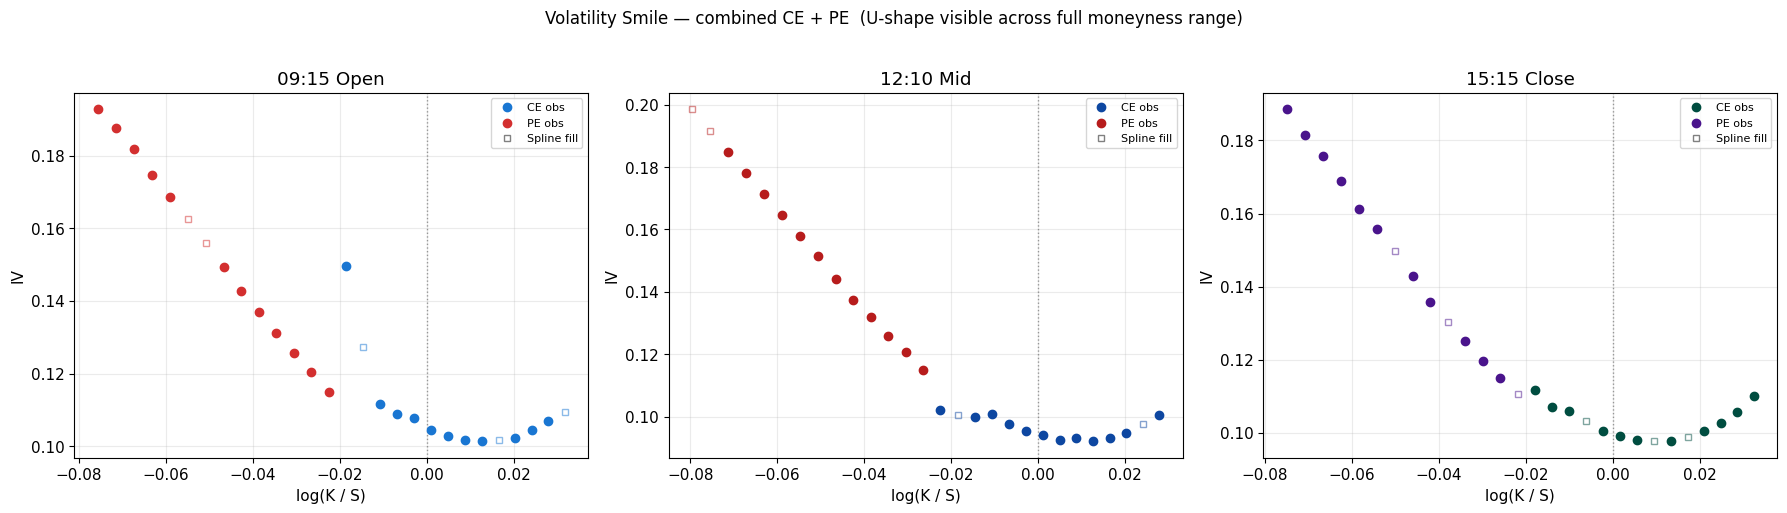

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
_day_rows = frame[frame['day_num'] == 5]

for ax, (bar_idx, lbl, cc, pc) in zip(axes, [
    (0,  '09:15 Open',       '#1976D2', '#D32F2F'),
    (37, '12:10 Mid',        '#0D47A1', '#B71C1C'),
    (72, '15:15 Close',      '#004D40', '#4A148C'),
]):
    sub = _day_rows[_day_rows['bar'] == bar_idx]
    if sub.empty: ax.set_title(f'{lbl} — no data'); continue
    row = sub.iloc[0]; ri = sub.index[0]
    px  = float(row['underlying_price'])

    for col in calls:
        lm = np.log(registry[col]['k'] / px)
        if pd.notna(row[col]): ax.plot(lm, float(row[col]), 'o', color=cc, ms=6, zorder=3)
        else:
            sp = smile_cache.get((ri, col), np.nan)
            if pd.notna(sp): ax.plot(lm, sp, 's', color=cc, ms=5, alpha=0.5, markerfacecolor='none')

    for col in puts:
        lm = np.log(registry[col]['k'] / px)
        if pd.notna(row[col]): ax.plot(lm, float(row[col]), 'o', color=pc, ms=6, zorder=3)
        else:
            sp = smile_cache.get((ri, col), np.nan)
            if pd.notna(sp): ax.plot(lm, sp, 's', color=pc, ms=5, alpha=0.5, markerfacecolor='none')

    ax.axvline(0, color='#424242', ls=':', lw=1, alpha=0.5)
    ax.set_xlabel('log(K / S)'); ax.set_ylabel('IV'); ax.set_title(lbl); ax.grid(alpha=0.25)
    ax.legend(handles=[
        Line2D([0],[0], marker='o', color=cc, label='CE obs', linestyle='None', ms=6),
        Line2D([0],[0], marker='o', color=pc, label='PE obs', linestyle='None', ms=6),
        Line2D([0],[0], marker='s', color='grey', label='Spline fill', linestyle='None',
               ms=5, markerfacecolor='none'),
    ], fontsize=8)

fig.suptitle('Volatility Smile — combined CE + PE  (U-shape visible across full moneyness range)',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('/kaggle/working/smile_curve.png', dpi=130, bbox_inches='tight')
plt.show()


## 7. Feature Matrix

### Feature groups

| Group | Features | Financial motivation |
|---|---|---|
| Smile position | `lm`, `moneyness`, `std_lm`, `rank` | Where on the smile curve does this strike sit? |
| Term structure | `dte`, `bar`, `bar_pct`, `day_num`, `early` | DTE drives gamma; intraday position drives liquidity |
| Surface shape | 16 descriptors from `shape_stats` | Current market regime — level, skew, curvature |
| Time-series lags | `lag1/2`, `roll3/10`, `velocity` | IV is autocorrelated; recent history is a strong prior |
| Market dynamics | `ret5m`, `ret5m × is_call` | Leverage effect: downside moves lift call IV disproportionately |
| Interactions | 5 cross terms | moneyness × spline confidence, DTE × moneyness, etc. |


In [11]:
FEAT_STRUCT = [
    'lm','moneyness','std_lm','is_call','rank',
    'dte','bar','bar_pct','day_num','early',
    'spot','atm_global','atm_c','atm_p','atm_mid',
    'avg_c','avg_p','lo_c','lo_p','n_c','n_p',
    'nc_ratio','np_ratio','sp_conf',
    'skew','disp','curv_c','curv_p','wing','bgap',
    'lag1','lag2','roll3','roll10','velocity',
    'lag1_f','roll3_f','roll10_f','g_lag','sp_val',
    'ret5m','ret5m_c',
]
FEAT_CROSS = ['lag1_sp_ratio','lm_sp_conf','lm_nobs','disp_rank','dte_lm']
ALL_FEATS  = list(dict.fromkeys(FEAT_STRUCT + FEAT_CROSS))
print(f"Feature count: {len(ALL_FEATS)}  ({len(FEAT_STRUCT)} structural + {len(FEAT_CROSS)} cross-terms)")


Feature count: 47  (42 structural + 5 cross-terms)


### 7.1 Wide → Long Reshape

In [12]:
print("Building long-format feature table...")
rows = []
for ri, ts in frame.iterrows():
    px     = float(ts['underlying_price'])
    ss     = shape_stats(ts, px)
    atm_v  = ss['atm_mid'] if pd.notna(ss['atm_mid']) else 0.20
    tau    = max(0.5, float(ts['dte'])) / 365.0
    g_lag  = bar_means[ri-1] if ri > 0 else 0.20
    n_ce   = len([c for c in calls if pd.notna(ts[c])])
    n_pe   = len([c for c in puts  if pd.notna(ts[c])])

    for col in iv_names:
        k       = registry[col]['k']
        is_call = 1 if registry[col]['t'] == 'CE' else 0
        lm      = np.log(k / px)
        sp_val  = smile_cache.get((ri, col), np.nan)
        rank    = (call_ks.index(k)/max(1,len(call_ks)-1) if is_call
                   else put_ks.index(k)/max(1,len(put_ks)-1))
        n_same  = n_ce if is_call else n_pe
        rows.append({
            'ri':ri,'col':col,
            'iv': float(ts[col]) if pd.notna(ts[col]) else np.nan,
            'is_missing': int(pd.isna(ts[col])),
            'is_expiry':  int(ts['is_expiry']),
            'is_call': is_call,'k':k,'spot':px,
            'lm':lm,'moneyness':k/px,'std_lm':lm/(atm_v*np.sqrt(tau)),
            'rank':rank,'dte':int(ts['dte']),'bar':int(ts['bar']),
            'bar_pct':float(ts['bar_pct']),'day_num':int(ts['day_num']),
            'early':int(ts['day_num']<=1),'sp_val':sp_val,'g_lag':g_lag,
            'nc_ratio':n_ce/14.0,'np_ratio':n_pe/14.0,'sp_conf':n_same/14.0,
            'ret5m':float(ts['ret5m']),**ss})

lf = pd.DataFrame(rows).sort_values(['col','ri']).reset_index(drop=True)
print(f"Long table: {lf.shape}")
lf[['ri','col','iv','is_missing','lm','sp_val']].head(4)


Building long-format feature table...
Long table: (27300, 39)


,ri,col,iv,is_missing,lm,sp_val
0,0,NIFTY27JAN2623800PE,0.17840,0,-0.092696,0.175096
1,1,NIFTY27JAN2623800PE,0.17962,0,-0.093835,0.179414
2,2,NIFTY27JAN2623800PE,0.18010,0,-0.093756,0.179669
3,3,NIFTY27JAN2623800PE,0.18174,0,-0.093358,0.185790


### 7.2 Temporal Lag Features

The read-before-append pattern:
1. **Read** the history buffer → write lag values for bar T
2. **Append** the current observation → available for bar T+1 and later

This is the only mechanism needed to guarantee strict lookahead freedom for all lag features.


In [13]:
for f in ['lag1','lag2','roll3','roll10','velocity']:
    lf[f] = np.nan

for col_name, grp in lf.groupby('col'):
    for d_id, dgrp in grp.groupby('day_num'):
        pos  = dgrp.index.tolist()
        seq  = dgrp['iv'].values.copy()
        n    = len(seq)
        l1=np.full(n,np.nan); l2=np.full(n,np.nan)
        r3=np.full(n,np.nan); r10=np.full(n,np.nan); vel=np.full(n,np.nan)
        buf=[]
        for i,v in enumerate(seq):
            if len(buf)>=1: l1[i]=buf[-1]; r3[i]=np.mean(buf[-3:]); r10[i]=np.mean(buf[-10:])
            if len(buf)>=2: l2[i]=buf[-2]; vel[i]=buf[-1]-buf[-2]
            if not np.isnan(v): buf.append(v)
        lf.loc[pos,'lag1']=l1; lf.loc[pos,'lag2']=l2
        lf.loc[pos,'roll3']=r3; lf.loc[pos,'roll10']=r10; lf.loc[pos,'velocity']=vel

lf['lag1_f']   = lf['lag1'].fillna(lf['sp_val'])
lf['roll3_f']  = lf['roll3'].fillna(lf['sp_val'])
lf['roll10_f'] = lf['roll10'].fillna(lf['sp_val'])
lf['lag1_sp_ratio'] = lf['lag1_f'] / lf['sp_val'].clip(0.01)
lf['lm_sp_conf']    = lf['lm'].abs() * (1 - lf['sp_conf'])
lf['lm_nobs']       = lf['lm'].abs() * np.where(lf['is_call']==1, lf['n_c'], lf['n_p'])
lf['disp_rank']     = lf['disp'] * lf['rank']
lf['dte_lm']        = np.log(lf['dte'].clip(1)) * lf['lm'].abs()
lf['ret5m_c']       = lf['ret5m'].fillna(0) * lf['is_call']

print(f"Lag features done.  lag1 populated: {lf['lag1'].notna().sum():,} / {len(lf):,}")


Lag features done.  lag1 populated: 26,838 / 27,300


### 7.3 Residual Distribution Analysis

This plot motivates three design decisions: (1) separate CE/PE models, (2) zone-based alpha for calls, (3) dedicated expiry model.


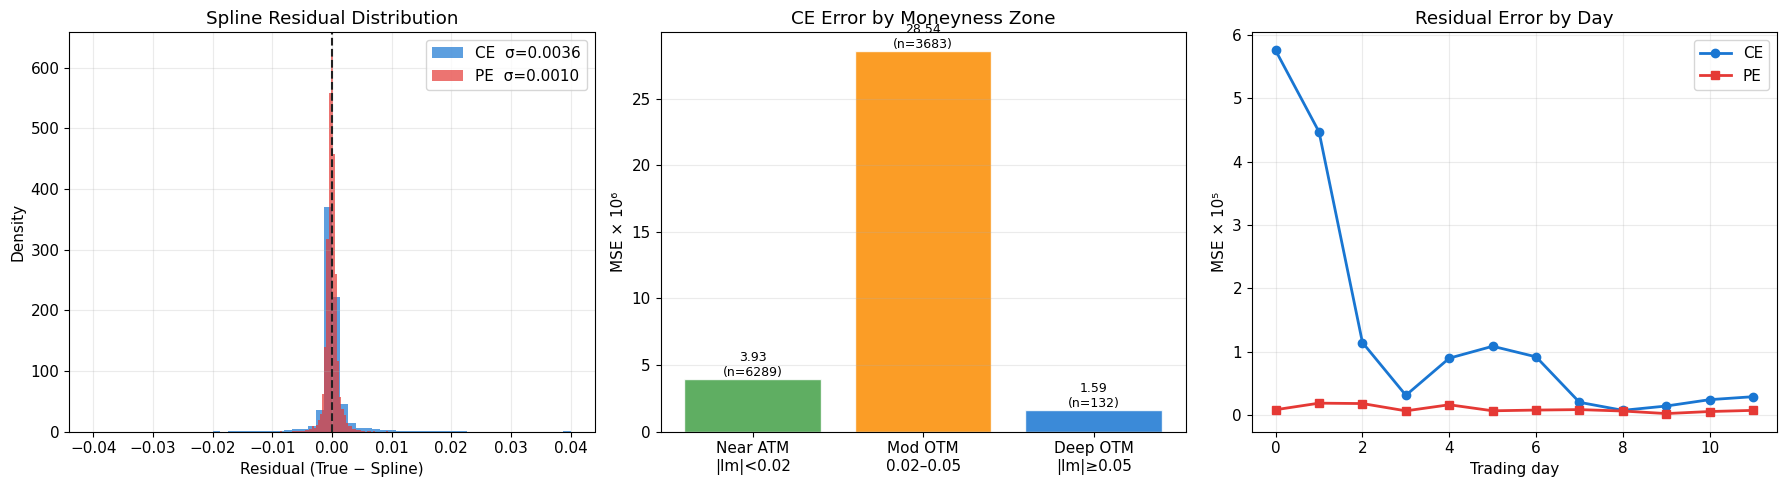

CE σ = 0.00359   PE σ = 0.00099   Ratio = 3.6×


In [14]:
trn = lf[(lf['is_expiry']==0) & (lf['is_missing']==0) & lf['iv'].notna()].copy()
trn['resid'] = trn['iv'] - trn['sp_val']
tc = trn[trn['is_call']==1]; tp = trn[trn['is_call']==0]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(tc['resid'].clip(-0.04,0.04), bins=60, alpha=0.7, color='#1976D2',
             density=True, label=f'CE  σ={tc["resid"].std():.4f}')
axes[0].hist(tp['resid'].clip(-0.04,0.04), bins=60, alpha=0.7, color='#E53935',
             density=True, label=f'PE  σ={tp["resid"].std():.4f}')
axes[0].axvline(0,color='#212121',ls='--',lw=1.5)
axes[0].set_xlabel('Residual (True − Spline)'); axes[0].set_ylabel('Density')
axes[0].set_title('Spline Residual Distribution'); axes[0].legend(); axes[0].grid(alpha=0.25)

tc_lm = tc['lm'].abs()
zone_def = [('Near ATM\n|lm|<0.02', tc_lm<0.02),
            ('Mod OTM\n0.02–0.05', (tc_lm>=0.02)&(tc_lm<0.05)),
            ('Deep OTM\n|lm|≥0.05', tc_lm>=0.05)]
mses = [(tc.loc[m,'resid']**2).mean()*1e6 for _,m in zone_def]
ns   = [m.sum() for _,m in zone_def]
bars = axes[1].bar([z[0] for z in zone_def], mses,
                   color=['#43A047','#FB8C00','#1976D2'], alpha=0.85, edgecolor='white')
axes[1].set_ylabel('MSE × 10⁶'); axes[1].set_title('CE Error by Moneyness Zone')
axes[1].grid(alpha=0.25, axis='y')
for b,v,n in zip(bars,mses,ns):
    axes[1].text(b.get_x()+b.get_width()/2, b.get_height()+0.05,
                 f'{v:.2f}\n(n={n})', ha='center', va='bottom', fontsize=9)

ce_d = tc.groupby('day_num').apply(lambda x:(x['resid']**2).mean()).reset_index()
pe_d = tp.groupby('day_num').apply(lambda x:(x['resid']**2).mean()).reset_index()
axes[2].plot(ce_d['day_num'], ce_d[0]*1e5,'o-',color='#1976D2',label='CE',lw=2)
axes[2].plot(pe_d['day_num'], pe_d[0]*1e5,'s-',color='#E53935',label='PE',lw=2)
axes[2].set_xlabel('Trading day'); axes[2].set_ylabel('MSE × 10⁵')
axes[2].set_title('Residual Error by Day'); axes[2].legend(); axes[2].grid(alpha=0.25)

plt.tight_layout()
plt.savefig('/kaggle/working/residual_analysis.png', dpi=130, bbox_inches='tight')
plt.show()
print(f"CE σ = {tc['resid'].std():.5f}   PE σ = {tp['resid'].std():.5f}   Ratio = {tc['resid'].std()/tp['resid'].std():.1f}×")


## 8.Gradient Boosting Residual Models

### Architecture

Three independent models:

| Model | Data | Params |
|---|---|---|
| `mdl_c` (LGB) + `mdl_c2` (CB) | CE calls, non-expiry | num_leaves=31, n_est=5000 |
| `mdl_p` (LGB) + `mdl_p2` (CB) | PE puts, non-expiry | same |
| `mdl_e` (LGB) | Expiry day | num_leaves=7, reg_lambda=4.0, early stopping |

Expiry model uses interleaved 20% validation (every 5th row) for early stopping — the data volume is only ~1,350 rows so a fixed split is cleaner than temporal.


In [15]:
_lgb_base = dict(learning_rate=0.002, num_leaves=31, min_child_samples=40,
                 subsample=0.75, colsample_bytree=0.70, reg_alpha=0.5, reg_lambda=1.0,
                 random_state=42, objective='regression', verbose=-1)
_cb_base  = dict(learning_rate=0.02, depth=6, subsample=0.75, colsample_bylevel=0.70,
                 reg_lambda=1.0, random_seed=42, verbose=0, loss_function='RMSE')

# CE models
_ce = lf[(lf['is_expiry']==0)&(lf['is_call']==1)&(lf['is_missing']==0)&lf['iv'].notna()].copy()
_ce['r'] = _ce['iv'] - _ce['sp_val']
med_c  = _ce[ALL_FEATS].median()
Xc, yc = _ce[ALL_FEATS].fillna(med_c), _ce['r'].values
mdl_c  = lgb.LGBMRegressor(n_estimators=5000, **_lgb_base); mdl_c.fit(Xc, yc)
mdl_c2 = CatBoostRegressor(iterations=3000, **_cb_base);     mdl_c2.fit(Xc, yc)
print(f"CE  trained: {len(Xc):,} rows")

# PE models
_pe = lf[(lf['is_expiry']==0)&(lf['is_call']==0)&(lf['is_missing']==0)&lf['iv'].notna()].copy()
_pe['r'] = _pe['iv'] - _pe['sp_val']
med_p  = _pe[ALL_FEATS].median()
Xp, yp = _pe[ALL_FEATS].fillna(med_p), _pe['r'].values
mdl_p  = lgb.LGBMRegressor(n_estimators=5000, **_lgb_base); mdl_p.fit(Xp, yp)
mdl_p2 = CatBoostRegressor(iterations=3000, **_cb_base);     mdl_p2.fit(Xp, yp)
print(f"PE  trained: {len(Xp):,} rows")

# Expiry model
_ex = lf[(lf['is_expiry']==1)&(lf['is_missing']==0)&lf['iv'].notna()].copy().reset_index(drop=True)
_ex['r'] = _ex['iv'] - _ex['sp_val']
_val  = (_ex.index % 5 == 0)
med_e = _ex.loc[~_val, ALL_FEATS].median()
Xe_tr, ye_tr = _ex.loc[~_val, ALL_FEATS].fillna(med_e), _ex.loc[~_val,'r'].values
Xe_va, ye_va = _ex.loc[ _val, ALL_FEATS].fillna(med_e), _ex.loc[ _val,'r'].values
mdl_e = lgb.LGBMRegressor(n_estimators=8000, learning_rate=0.001, num_leaves=7,
                           min_child_samples=30, subsample=0.70, colsample_bytree=0.60,
                           reg_alpha=1.5, reg_lambda=4.0, random_state=42,
                           objective='regression', verbose=-1)
mdl_e.fit(Xe_tr, ye_tr, eval_set=[(Xe_va, ye_va)],
          callbacks=[lgb.early_stopping(150,verbose=False), lgb.log_evaluation(9999)])
print(f"Exp trained: {len(Xe_tr):,} rows  best_iter={mdl_e.best_iteration_:,}")


CE  trained: 10,104 rows
PE  trained: 10,044 rows
Exp trained: 1,353 rows  best_iter=8,000


### 8.1 Feature Importance

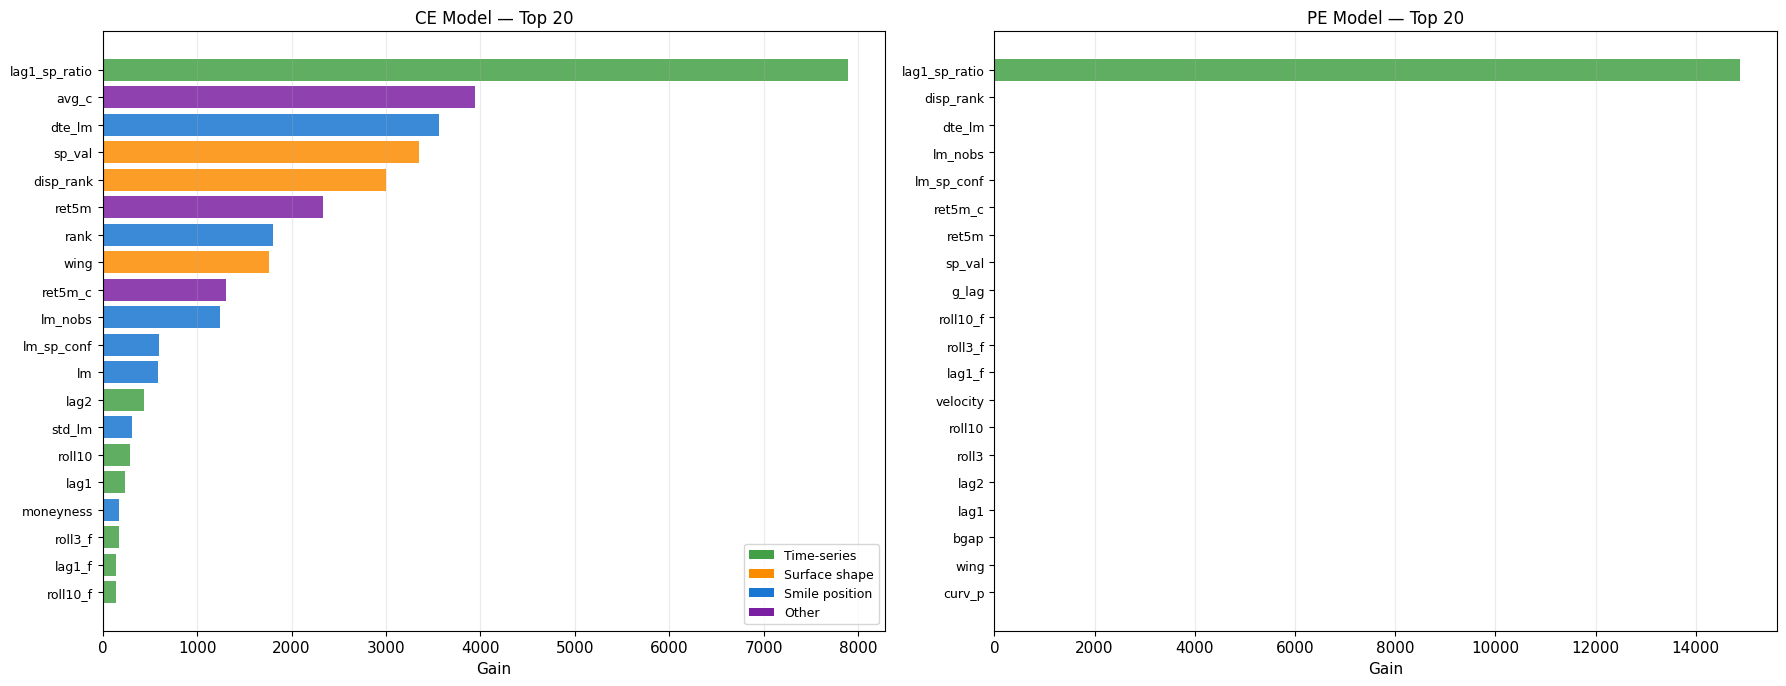

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
for ax, mdl, title, clr in [
    (axes[0], mdl_c,  'CE Model — Top 20', '#1976D2'),
    (axes[1], mdl_p,  'PE Model — Top 20', '#E53935'),
]:
    imp = pd.Series(mdl.feature_importances_, index=ALL_FEATS).sort_values(ascending=True).tail(20)
    fc  = ['#43A047' if any(x in f for x in ['lag','roll','velocity','g_lag']) else
           '#FB8C00' if any(x in f for x in ['sp_val','atm','disp','skew','curv','wing']) else
           clr       if any(x in f for x in ['lm','money','rank']) else '#7B1FA2'
           for f in imp.index]
    ax.barh(range(len(imp)), imp.values, color=fc, alpha=0.85)
    ax.set_yticks(range(len(imp))); ax.set_yticklabels(imp.index, fontsize=9)
    ax.set_xlabel('Gain'); ax.set_title(title, fontsize=12); ax.grid(alpha=0.25, axis='x')
axes[0].legend(handles=[Patch(facecolor='#43A047',label='Time-series'),
                          Patch(facecolor='#FB8C00',label='Surface shape'),
                          Patch(facecolor='#1976D2',label='Smile position'),
                          Patch(facecolor='#7B1FA2',label='Other')], fontsize=9, loc='lower right')
plt.tight_layout()
plt.savefig('/kaggle/working/feature_importance.png', dpi=130, bbox_inches='tight')
plt.show()


## 9. Final Predictions

Apply the zone-weighted ensemble correction to the Stage 1 baseline:

$$\widehat{\text{IV}} = \text{sp\_val} + \alpha_{\text{zone}} \times (0.5 \cdot \text{LGB} + 0.5 \cdot \text{CB})$$


In [17]:
output = filled.copy()
gap    = lf['is_missing'] == 1
exp    = lf['is_expiry']  == 1
call   = lf['is_call']    == 1

# CE calls
ce_rows = lf[~exp & gap & call]
if len(ce_rows):
    Xi  = ce_rows[ALL_FEATS].fillna(med_c)
    ens = 0.5*mdl_c.predict(Xi) + 0.5*mdl_c2.predict(Xi)
    alm = ce_rows['lm'].abs().values
    av  = np.where(alm<0.02, W_CE_ATM, np.where(alm<0.05, W_CE_MID, W_CE_WING))
    pv  = np.clip(ce_rows['sp_val'].values + av*ens, 0.005, None)
    for (ri,col),v in zip(zip(ce_rows['ri'],ce_rows['col']), pv):
        output.at[int(ri), col] = v

# PE puts
pe_rows = lf[~exp & gap & ~call]
if len(pe_rows):
    Xi  = pe_rows[ALL_FEATS].fillna(med_p)
    ens = 0.5*mdl_p.predict(Xi) + 0.5*mdl_p2.predict(Xi)
    alm = pe_rows['lm'].abs().values
    av  = np.where(alm<0.02, W_PE, np.where(alm<0.05, W_PE, W_PE))
    pv  = np.clip(pe_rows['sp_val'].values + av*ens, 0.005, None)
    for (ri,col),v in zip(zip(pe_rows['ri'],pe_rows['col']), pv):
        output.at[int(ri), col] = v

# Expiry
ex_rows = lf[exp & gap]
if len(ex_rows):
    Xi = ex_rows[ALL_FEATS].fillna(med_e)
    pv = np.clip(ex_rows['sp_val'].values + W_EXP*mdl_e.predict(Xi), 0.005, None)
    for (ri,col),v in zip(zip(ex_rows['ri'],ex_rows['col']), pv):
        output.at[int(ri), col] = v

for col in iv_names:
    if output[col].isna().any():
        fb = frame[col].median()
        output[col] = output[col].fillna(fb if pd.notna(fb) else 0.22)

tot = len(ce_rows)+len(pe_rows)+len(ex_rows)
print(f"CE:{len(ce_rows):,}  PE:{len(pe_rows):,}  Exp:{len(ex_rows):,}  Total:{tot:,}")
print(f"Remaining NaN : {output[iv_names].isna().sum().sum()}")
print(f"All positive  : {(output[iv_names]>0).all().all()}")


CE:2,496  PE:2,556  Exp:408  Total:5,460
Remaining NaN : 0
All positive  : True


### 9.1 Prediction Visualisations

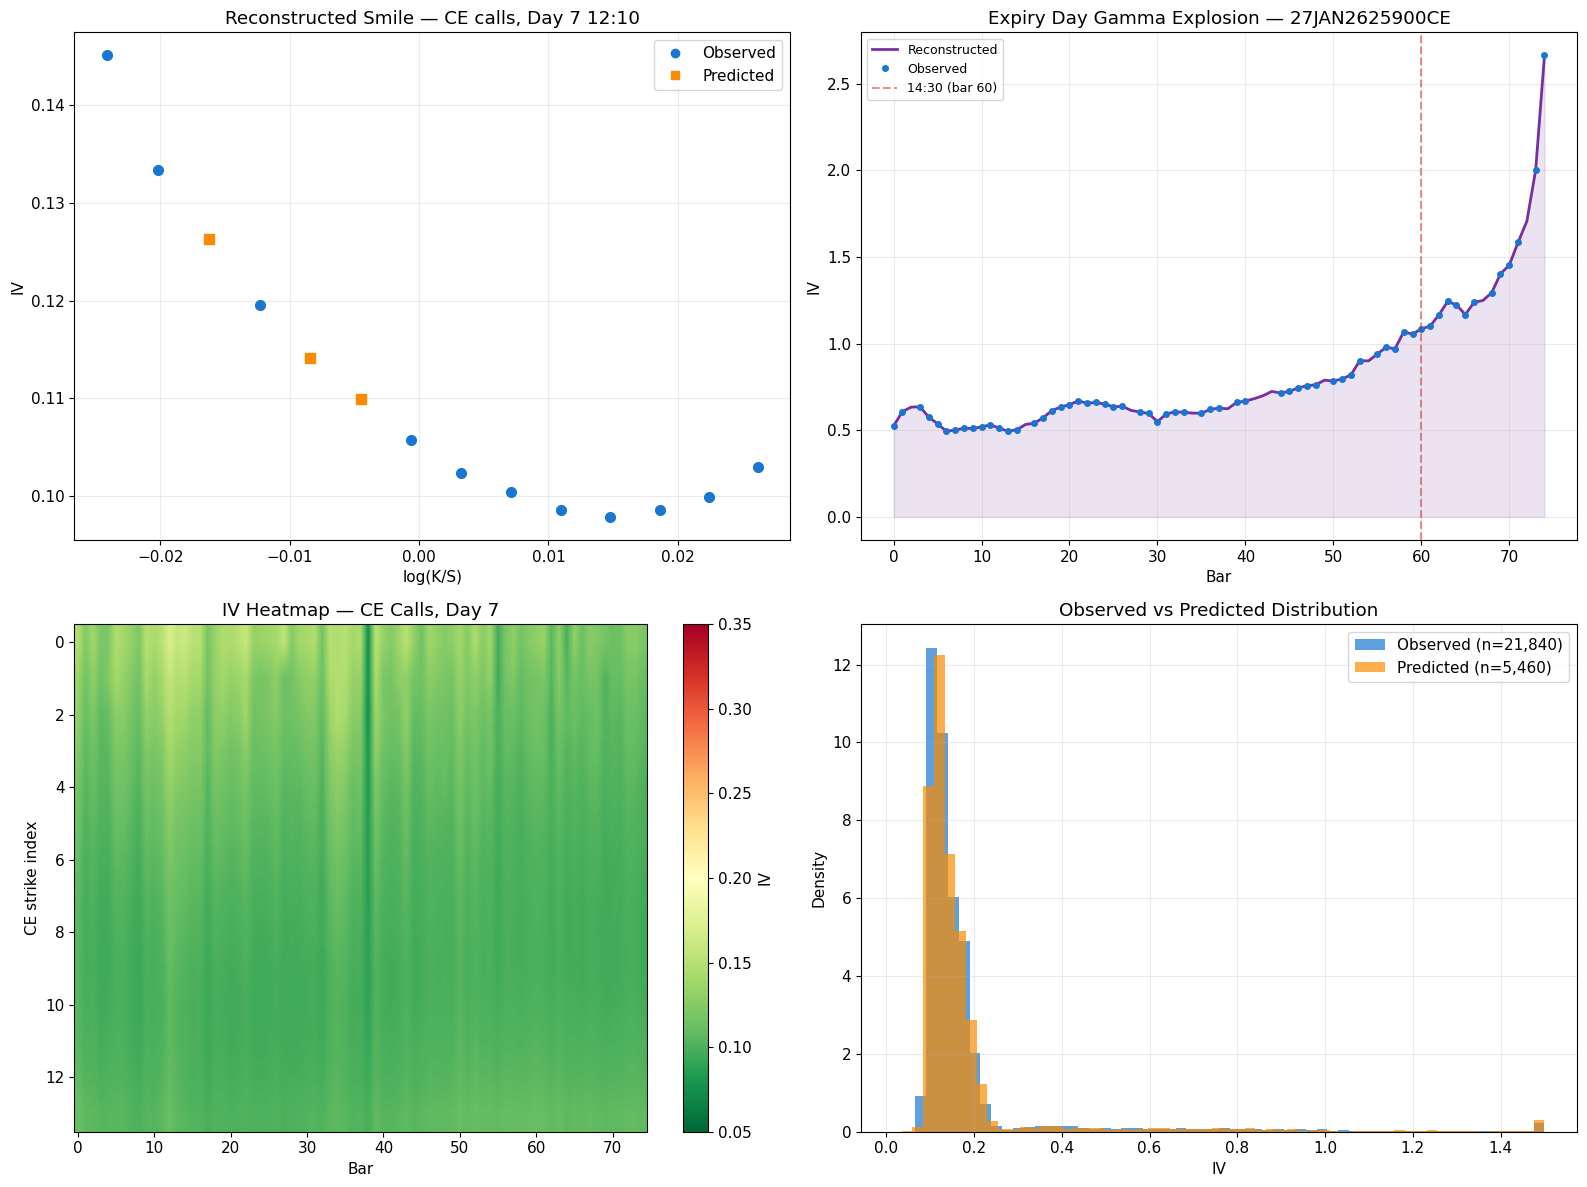

In [18]:
output['_dn'] = frame['day_num'].values
output['_bn'] = frame['bar'].values
output['_ex'] = frame['is_expiry'].values

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Reconstructed smile
ax = axes[0,0]
ref = frame[(frame['day_num']==6)&(frame['bar']==37)].iloc[0]
px  = float(ref['underlying_price']); ri = ref.name
for col in calls:
    lm  = np.log(registry[col]['k']/px)
    obs = float(frame.loc[ri,col]) if pd.notna(frame.loc[ri,col]) else None
    prd = float(output.loc[ri,col])
    ax.plot(lm, obs if obs else prd, 'o' if obs else 's',
            color='#1976D2' if obs else '#FB8C00', ms=7, zorder=3)
ax.plot([],[],'o',color='#1976D2',label='Observed'); ax.plot([],[],'s',color='#FB8C00',label='Predicted')
ax.set_xlabel('log(K/S)'); ax.set_ylabel('IV')
ax.set_title('Reconstructed Smile — CE calls, Day 7 12:10'); ax.legend(); ax.grid(alpha=0.25)

# Expiry gamma explosion
ax = axes[0,1]
exp_f  = frame[frame['is_expiry']==1].sort_values('bar')
mid_c  = calls[len(calls)//2]
obs_iv = [float(r[mid_c]) if pd.notna(r[mid_c]) else np.nan for _,r in exp_f.iterrows()]
prd_iv = [float(output.loc[r.name,mid_c]) for _,r in exp_f.iterrows()]
brs    = exp_f['bar'].tolist()
ax.plot(brs, prd_iv, '-', color='#6A1B9A', lw=2, label='Reconstructed', alpha=0.9)
ax.plot([b for b,v in zip(brs,obs_iv) if not np.isnan(v)],
        [v for v in obs_iv if not np.isnan(v)], 'o', color='#1976D2', ms=4, label='Observed')
ax.fill_between(brs, prd_iv, alpha=0.12, color='#6A1B9A')
ax.axvline(60, color='#C62828', ls='--', alpha=0.5, lw=1.5, label='14:30 (bar 60)')
ax.set_xlabel('Bar'); ax.set_ylabel('IV')
ax.set_title(f'Expiry Day Gamma Explosion — {mid_c[-14:]}'); ax.legend(fontsize=9); ax.grid(alpha=0.25)

# Heatmap
ax = axes[1,0]
hp = output[output['_dn']==6].set_index('_bn')[calls].astype(float)
if len(hp):
    im = ax.imshow(hp.T, aspect='auto', cmap='RdYlGn_r', interpolation='bilinear', vmin=0.05, vmax=0.35)
    ax.set_xlabel('Bar'); ax.set_ylabel('CE strike index')
    ax.set_title('IV Heatmap — CE Calls, Day 7'); plt.colorbar(im, ax=ax, label='IV')

# Distribution
ax = axes[1,1]
all_obs  = lf[lf['is_missing']==0]['iv'].dropna()
pred_all = [float(output.at[int(r['ri']),r['col']]) for _,r in lf[lf['is_missing']==1].iterrows()
            if pd.notna(output.at[int(r['ri']),r['col']])]
ax.hist(all_obs.clip(0,1.5), bins=60, alpha=0.7, color='#1976D2', density=True,
        label=f'Observed (n={len(all_obs):,})')
ax.hist(np.clip(pred_all,0,1.5), bins=60, alpha=0.7, color='#FB8C00', density=True,
        label=f'Predicted (n={len(pred_all):,})')
ax.set_xlabel('IV'); ax.set_ylabel('Density')
ax.set_title('Observed vs Predicted Distribution'); ax.legend(); ax.grid(alpha=0.25)

plt.tight_layout()
plt.savefig('/kaggle/working/final_predictions.png', dpi=130, bbox_inches='tight')
plt.show()


## 10. Submission Export

Restore the original CSV row order, melt to long format, keep only the originally-missing cells.


In [19]:
output['row_order'] = frame['row_order'].values
output = (output
    .sort_values('row_order')
    .drop(columns=['row_order','_cal','dte','bar','bar_pct','day_num',
                   'is_expiry','ret5m','spot_chg','_dn','_bn','_ex'], errors='ignore')
    .reset_index(drop=True))
output['datetime'] = raw['datetime'].values

melted  = output.melt(id_vars=['datetime'], value_vars=iv_names, var_name='col', value_name='pred')
orig_m  = raw[['datetime']+iv_names].melt(id_vars=['datetime'], value_vars=iv_names,
                                           var_name='col', value_name='orig')
melted['orig'] = orig_m['orig']

sub = melted[melted['orig'].isna()].copy()
sub['id'] = sub['datetime'] + SEP + sub['col']
sub = sub[['id','pred']].rename(columns={'pred':'value'}).sort_values('id').reset_index(drop=True)
sub.to_csv(SUBMIT_FILE, index=False)

print(f"File          : {SUBMIT_FILE}")
print(f"Rows          : {len(sub)}  (expected 5460)")
print(f"Range         : {sub['value'].min():.4f} → {sub['value'].max():.4f}")
print(f"All positive  : {(sub['value']>0).all()}")
print(f"None above 10 : {(sub['value']<10).all()}")
print(f"No NaN        : {sub['value'].notna().all()}")
sub.head(8)


File          : /kaggle/working/submission.csv
Rows          : 5460  (expected 5460)
Range         : 0.0355 → 5.8082
All positive  : True
None above 10 : True
No NaN        : True


,id,value
0,07-01-2026 09:15||NIFTY27JAN2624100PE,0.163743
1,07-01-2026 09:15||NIFTY27JAN2625500CE,0.114391
2,07-01-2026 09:15||NIFTY27JAN2625800CE,0.101220
3,07-01-2026 09:20||NIFTY27JAN2624000PE,0.170289
4,07-01-2026 09:20||NIFTY27JAN2624200PE,0.159831
5,07-01-2026 09:20||NIFTY27JAN2624800PE,0.128134
6,07-01-2026 09:20||NIFTY27JAN2625000PE,0.118581
7,07-01-2026 09:20||NIFTY27JAN2625300CE,0.105447
